In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [179]:
data = pd.read_csv("smartcart_customers.csv")

In [180]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [181]:
data.shape

(2240, 22)

In [182]:
data.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [183]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [184]:
#Data Preprocessing
data['Income'] = data['Income'].astype(str)
data['Income'] = pd.to_numeric(data['Income'], errors='coerce')
data['Income'].fillna(data['Income'].median(), inplace=True)
data.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_14908\4052726367.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Income'].fillna(data['Income'].median(), inplace=True)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [185]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [186]:
data.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
Response                 int64
dtype: object

In [187]:
#Feature Engineering 
#Age
data["Age"] = 2026 - data["Year_Birth"]

In [188]:
#Customer Joining Date
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst = True)
refrence_date = data["Dt_Customer"].max()
data["Customer_Tenure_Days"] = refrence_date - data["Dt_Customer"]

In [189]:
#Spending
data["Total_Spending"] = data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]
data["Total_Children's"] = data["Kidhome"]+data["Teenhome"]

In [190]:
#Education
data["Education"] = data["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "PhD" : "Postgraduate", "Master": "Postgraduate"})

In [191]:
#Marital_Status
data["Living_with"] = data["Marital_Status"].replace({
    "Married" : "Patner", "Together" : "Patner",
    "Single" : "Alone", "Divorced" : "Alone", "Widow" : "Alone",
    "Absurd" : "Alone", "YOLO": "Alone"
})

In [192]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children's,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663 days,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113 days,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312 days,776,0,Patner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139 days,53,1,Patner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161 days,422,1,Patner


In [193]:
#Drop
cols = ["ID", "Marital_Status", "Year_Birth", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols
clean_data = data.drop(columns = cols_to_drop)

In [194]:
clean_data.shape

(2240, 15)

In [195]:
clean_data.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children's,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,Patner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,Patner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,Patner


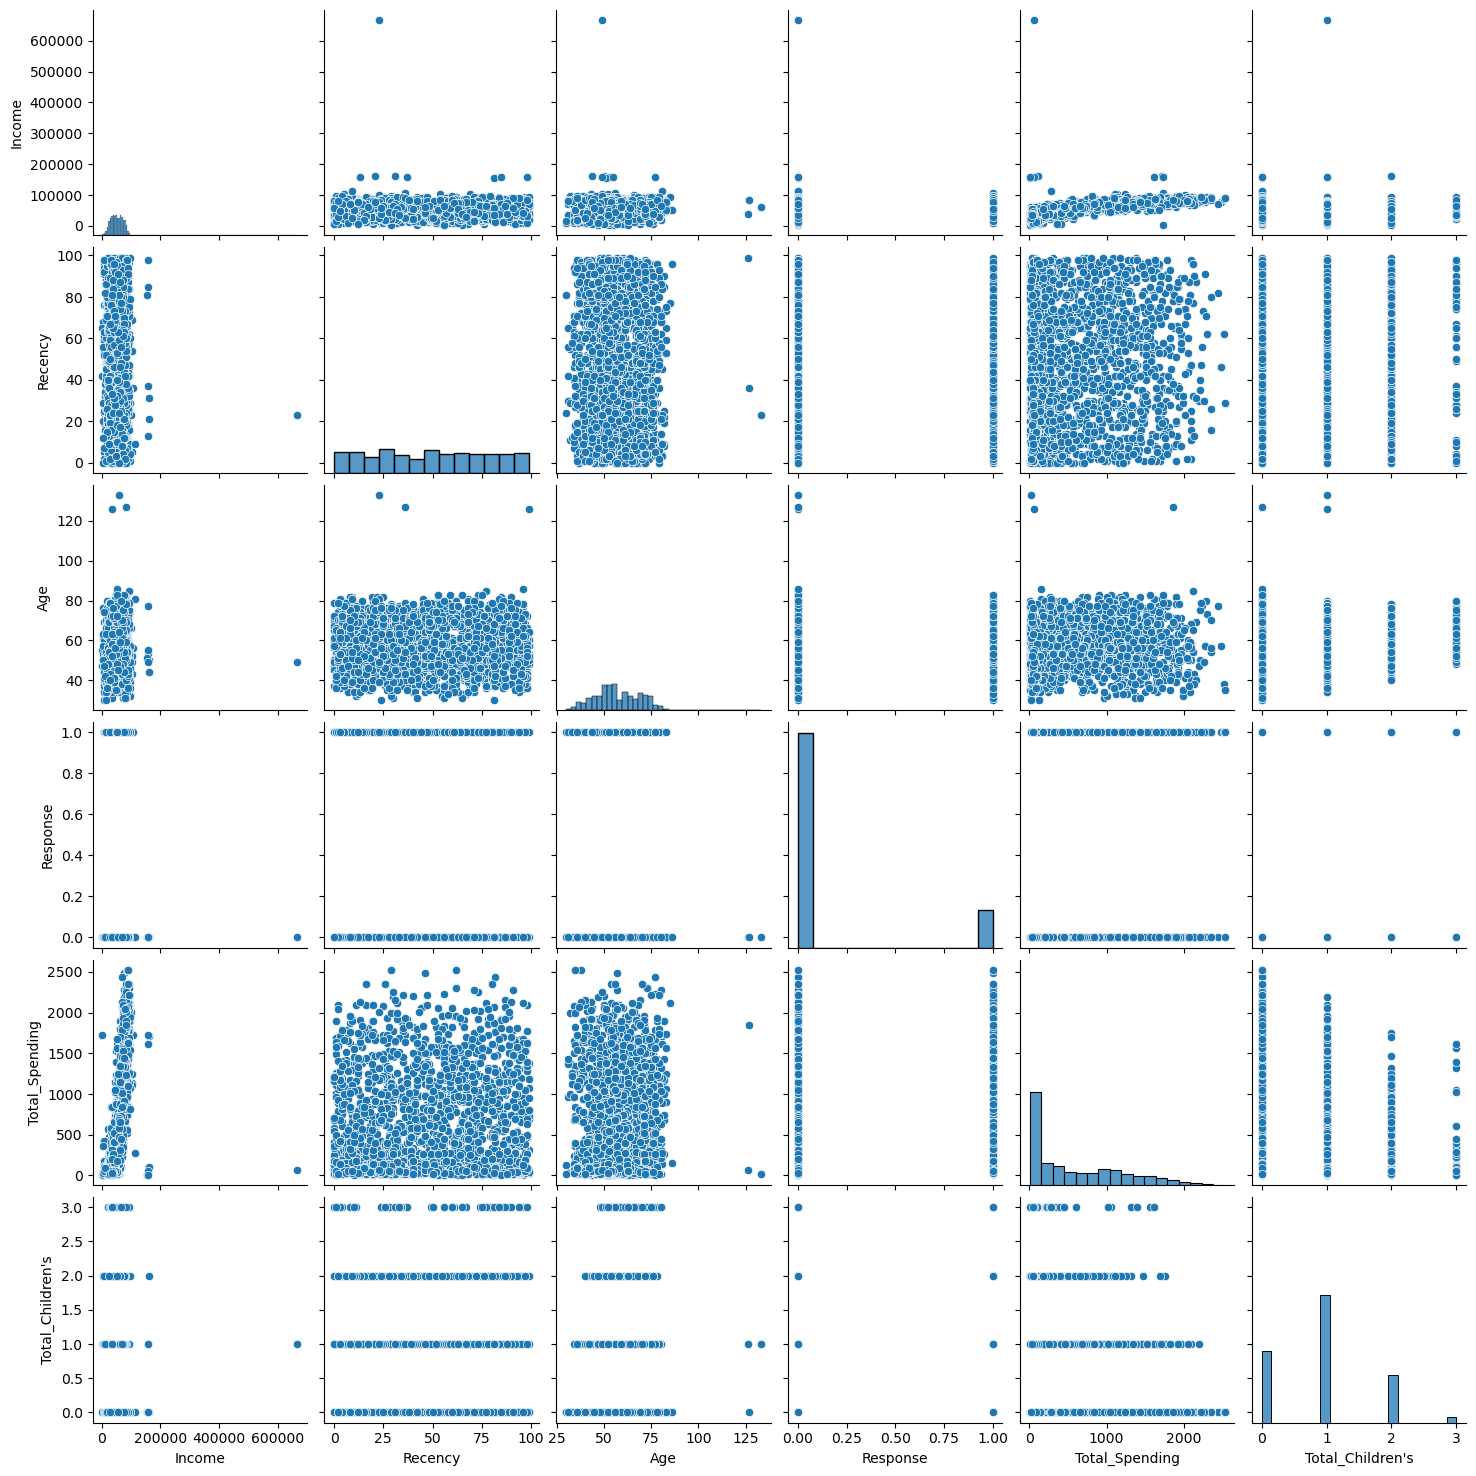

In [196]:
#checking Outliers
cols = ["Income", "Recency", "Age", "Response", "Total_Spending", "Total_Children's"]
sns.pairplot(clean_data[cols])
plt.show()

In [197]:
#Remove outliers
print("data size with outliers: ", len(clean_data))
clean_data = clean_data[(clean_data["Age"] < 90 )]
clean_data = clean_data[(clean_data["Income"] < 600_000 )]

print("data size without outliers: ", len(clean_data))

data size with outliers:  2240
data size without outliers:  2236


In [198]:
#Heatmap
corr = clean_data.corr(numeric_only = True)

<Axes: >

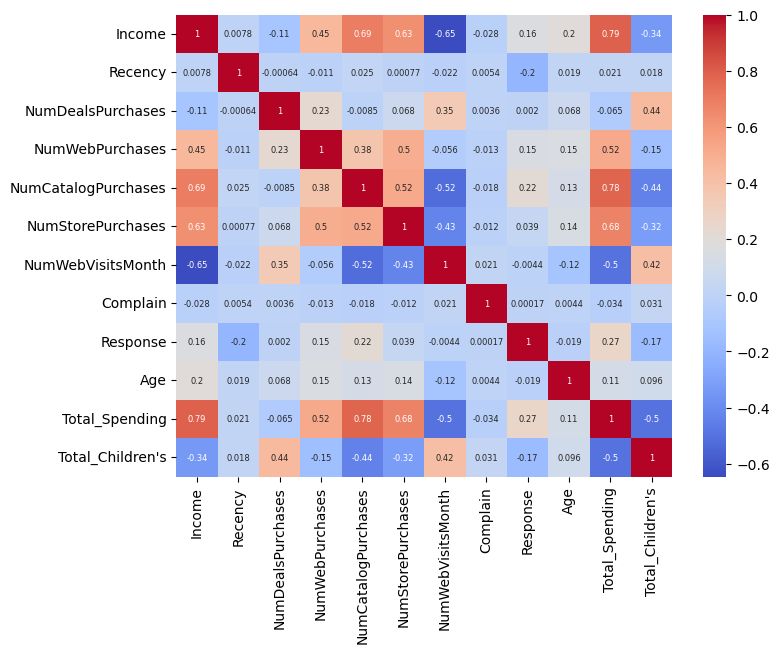

In [199]:
plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size" : 6},
    cmap = "coolwarm"
)

In [200]:
#one hot encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cols = ["Education", "Living_with"]

encoded = ohe.fit_transform(clean_data[cols])

In [201]:
data_encoded = pd.DataFrame(encoded.toarray(), columns = ohe.get_feature_names_out(cols))

In [202]:
final = pd.concat([clean_data.drop(columns = cols), data_encoded], axis = 1)
final

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children's,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Patner
0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663 days,1617.0,0.0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113 days,27.0,2.0,1.0,0.0,0.0,1.0,0.0
2,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312 days,776.0,0.0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139 days,53.0,1.0,1.0,0.0,0.0,0.0,1.0
4,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161 days,422.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,52869.0,40.0,3.0,3.0,1.0,4.0,7.0,0.0,1.0,72.0,622 days,172.0,2.0,NaN,NaN,NaN,NaN,NaN
192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,1.0,0.0,0.0,0.0,1.0
239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,1.0,0.0,0.0,0.0,1.0
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,0.0,1.0,0.0,0.0,1.0


In [203]:
final = pd.concat([clean_data.drop(columns = cols), data_encoded], axis = 1)
final

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children's,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Patner
0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663 days,1617.0,0.0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113 days,27.0,2.0,1.0,0.0,0.0,1.0,0.0
2,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312 days,776.0,0.0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139 days,53.0,1.0,1.0,0.0,0.0,0.0,1.0
4,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161 days,422.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,52869.0,40.0,3.0,3.0,1.0,4.0,7.0,0.0,1.0,72.0,622 days,172.0,2.0,NaN,NaN,NaN,NaN,NaN
192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,1.0,0.0,0.0,0.0,1.0
239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,1.0,0.0,0.0,0.0,1.0
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,0.0,1.0,0.0,0.0,1.0


In [204]:
final["Customer_Tenure_Days"] = final["Customer_Tenure_Days"].dt.days


In [205]:
X= final

In [206]:
#Scaling
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)


In [207]:
final.isnull().sum()

Income                     4
Recency                    4
NumDealsPurchases          4
NumWebPurchases            4
NumCatalogPurchases        4
NumStorePurchases          4
NumWebVisitsMonth          4
Complain                   4
Response                   4
Age                        4
Customer_Tenure_Days       4
Total_Spending             4
Total_Children's           4
Education_Graduate         4
Education_Postgraduate     4
Education_Undergraduate    4
Living_with_Alone          4
Living_with_Patner         4
dtype: int64

In [208]:
from sklearn.preprocessing import StandardScaler

In [209]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [210]:
#Visualize
#2D
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

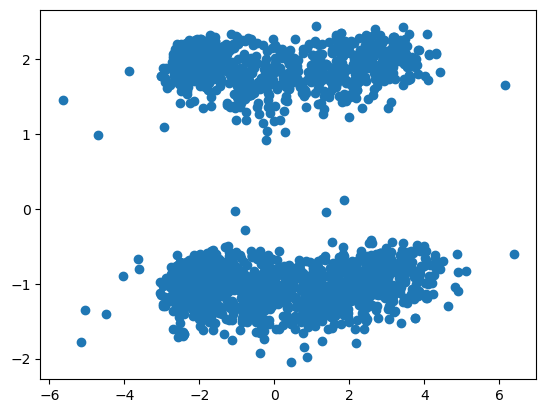

In [211]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
)

In [212]:
print("Explained_variance_ratio: ", pca.explained_variance_ratio_)

Explained_variance_ratio:  [0.23013474 0.1121041 ]


In [213]:
#3D
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

In [214]:
print("Explained_variance_ratio: ", pca.explained_variance_ratio_)

Explained_variance_ratio:  [0.23013474 0.1121041  0.10141533]


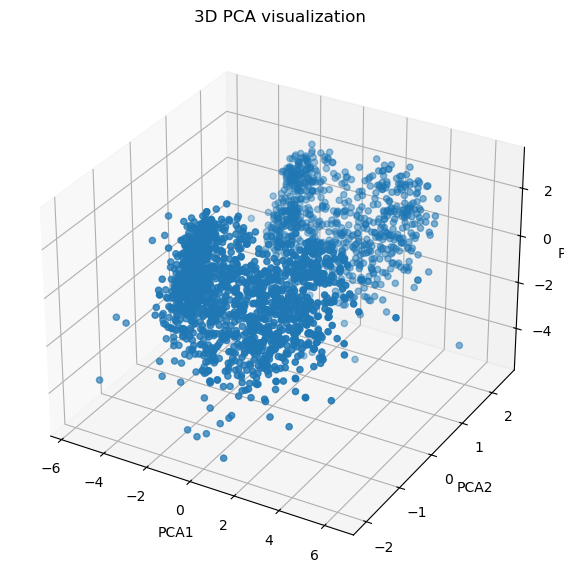

In [215]:
fig = plt.figure(figsize=(8,7))

ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.title("3D PCA visualization")

plt.show()




In [216]:
##Elbow
from sklearn.cluster import KMeans
wcss= []

for k in range(1,11):
    kmeans = KMeans(n_clusters= k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


Text(0.5, 1.0, 'Elbow Method')

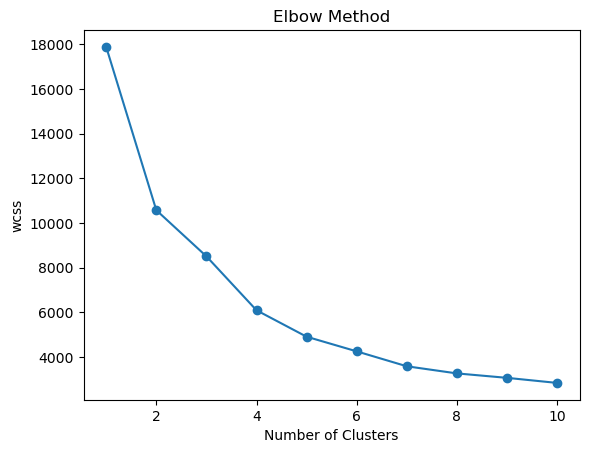

In [217]:
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.title("Elbow Method")

In [218]:
from kneed import KneeLocator
knee = KneeLocator(range(1,11), wcss, curve = "convex" , direction = "decreasing")
optimal_k = knee.elbow

In [219]:
print("best_K: ",optimal_k)

best_K:  4


In [220]:
#Silhouette
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
   
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    print("cluster :", k, "silhouette_score :",score)

cluster : 2 silhouette_score : 0.37598475778398127
cluster : 3 silhouette_score : 0.3645562342286285
cluster : 4 silhouette_score : 0.41472110882525026
cluster : 5 silhouette_score : 0.41407059855223105
cluster : 6 silhouette_score : 0.4124458105287443
cluster : 7 silhouette_score : 0.3910447924623278
cluster : 8 silhouette_score : 0.37912475779505056
cluster : 9 silhouette_score : 0.37821998035910687
cluster : 10 silhouette_score : 0.3824203002695386


Text(0.5, 1.0, 'silhouette_score')

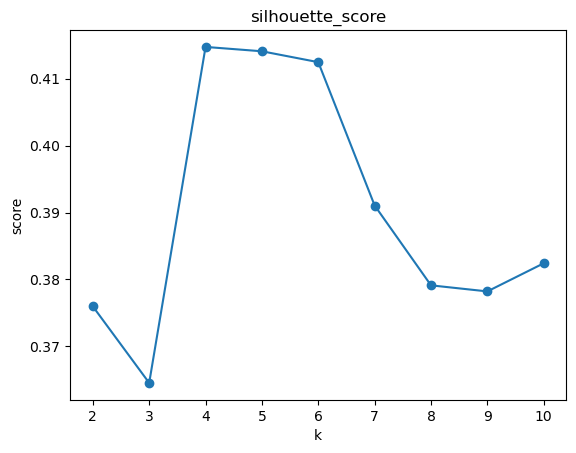

In [221]:
plt.plot(range(2,11),scores, marker="o")
plt.xlabel("k")
plt.ylabel("score")
plt.title("silhouette_score")

Text(0.5, 1.0, 'Elbow Method vs Silhouette Score')

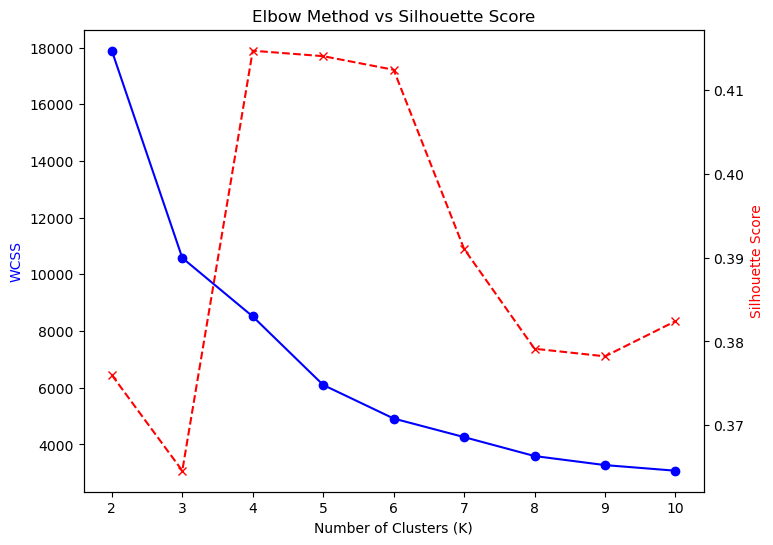

In [222]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color='blue', label='WCSS')
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS", color='blue')
ax2 = ax1.twinx()

ax2.plot(k_range, scores[:len(k_range)], marker='x', linestyle='--', color='red', label='Silhouette Score')
ax2.set_ylabel("Silhouette Score", color='red')

plt.title("Elbow Method vs Silhouette Score")

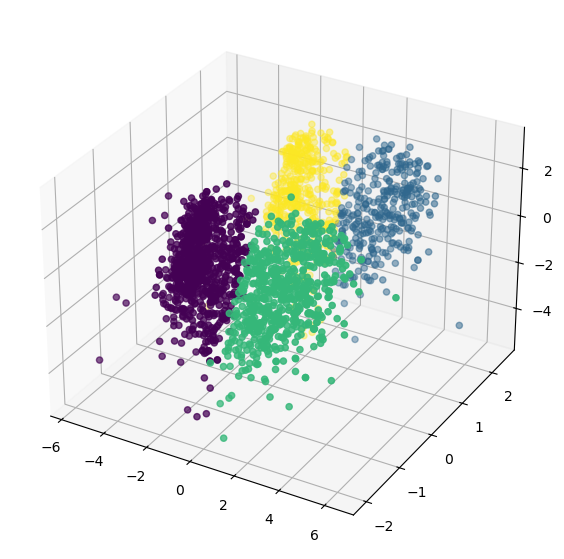

In [223]:
#kmeans clustering
kmeans = KMeans(n_clusters = 4, random_state =42)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,7))

ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c = labels)


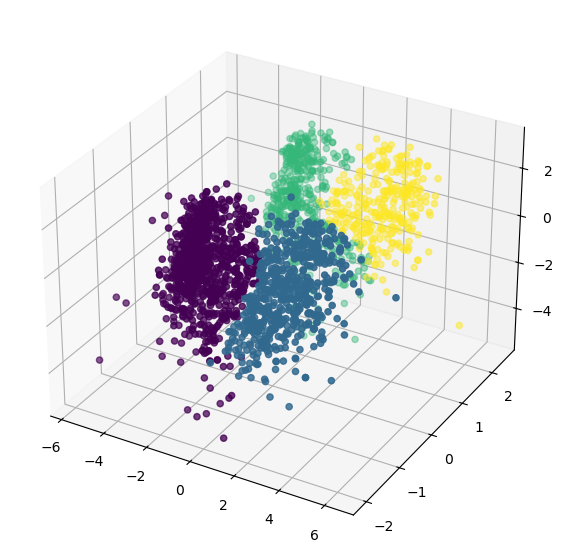

In [224]:
from sklearn.cluster import AgglomerativeClustering
algo = AgglomerativeClustering(n_clusters=4, linkage = "ward")
labells = algo.fit_predict(X_pca)

fig = plt.figure(figsize=(8,7))

ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c = labells)


In [229]:
#Characterization of clusters
final["cluster"] = labels

In [230]:
final.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children's,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Patner,cluster
0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663.0,1617.0,0.0,1.0,0.0,0.0,1.0,0.0,1
1,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113.0,27.0,2.0,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312.0,776.0,0.0,1.0,0.0,0.0,0.0,1.0,2
3,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139.0,53.0,1.0,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161.0,422.0,1.0,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

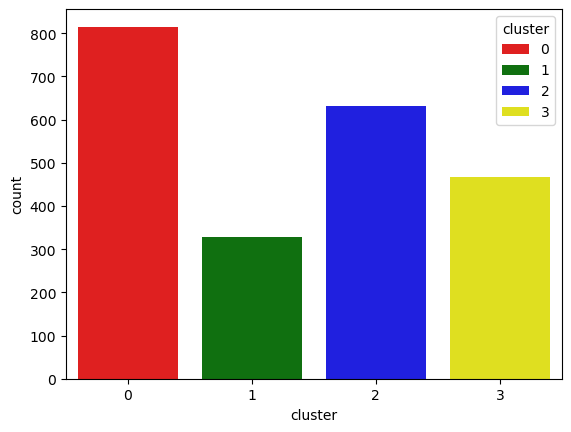

In [231]:
pal = ["Red", "green", "blue", "yellow"]
sns.countplot(x=final["cluster"],palette = pal , hue=final["cluster"])


<Axes: xlabel='Total_Spending', ylabel='Income'>

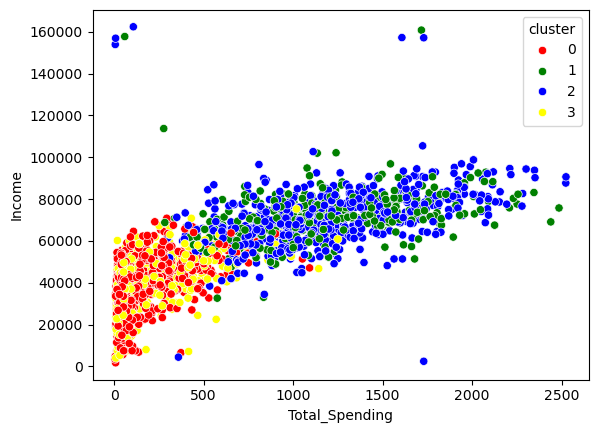

In [233]:
#INcome & Spending pattern
sns.scatterplot(x = final["Total_Spending"], y =final["Income"], hue = final["cluster"], palette = pal)

In [234]:
cluster_sum = final.groupby("cluster").mean()

In [235]:
print(cluster_sum)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        37143.494458  49.642857           2.496305         2.838670   
1        72045.807927  46.975610           1.829268         5.603659   
2        70678.893027  50.467512           2.129952         5.812995   
3        38228.217204  47.873118           2.645161         2.858065   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.772167           3.742611           6.498768  0.013547   
1                   5.204268           8.250000           3.490854  0.003049   
2                   5.085578           8.654517           3.838352  0.009509   
3                   0.886022           3.769892           6.556989  0.004301   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         